# Graph Property Correlation Analysis
Explores how graph properties relate to `chromatic_number`.

## Python setup 
1. Init & activate virtual env: `python3 -m venv .venv && source .venv/bin/activate`
2. Install requirements: `pip install -r requirements.txt`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

CSV_PATH = 'results_5vertex.csv'
TARGET = 'chromatic_number'

## 1. Load & overview

In [3]:
df = pd.read_csv(CSV_PATH)

# Normalise boolean columns (stored as strings in some exports)
bool_cols = ['is_isomorphic', 'is_cyclic', 'has_hamiltonian_path']
for c in bool_cols:
    if df[c].dtype == object:
        df[c] = df[c].str.lower().map({'true': True, 'false': False})

print(f'Shape: {df.shape}')
df.head()

Shape: (1027080, 9)


,mask,num_edges,chromatic_number,is_isomorphic,is_cyclic,connectivity_number,stability_number,clique_number,has_hamiltonian_path
0,15,4,2,False,False,1,4,2,False
1,30,4,2,False,False,1,4,2,False
2,31,5,2,False,True,1,4,2,False
3,45,4,2,False,False,1,3,2,False
4,46,4,2,False,False,1,3,2,False


In [4]:
df.describe(include='all')

,mask,num_edges,chromatic_number,is_isomorphic,is_cyclic,connectivity_number,stability_number,clique_number,has_hamiltonian_path
count,1.027080e+06,1.027080e+06,1.027080e+06,1027080,1027080,1.027080e+06,1.027080e+06,1.027080e+06,1027080
unique,NaN,NaN,NaN,2,2,NaN,NaN,NaN,2
top,NaN,NaN,NaN,True,True,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,1017716,1000650,NaN,NaN,NaN,929005
mean,5.286979e+05,1.008412e+01,2.026851e+00,NaN,NaN,2.204495e+00,2.059227e+00,3.506861e+00,NaN
std,3.014138e+05,2.168088e+00,1.616476e-01,NaN,NaN,8.207076e-01,4.141163e-01,6.579655e-01,NaN
min,1.500000e+01,4.000000e+00,2.000000e+00,NaN,NaN,1.000000e+00,1.000000e+00,2.000000e+00,NaN
25%,2.682098e+05,9.000000e+00,2.000000e+00,NaN,NaN,2.000000e+00,2.000000e+00,3.000000e+00,NaN
50%,5.289575e+05,1.000000e+01,2.000000e+00,NaN,NaN,2.000000e+00,2.000000e+00,3.000000e+00,NaN
75%,7.898532e+05,1.200000e+01,2.000000e+00,NaN,NaN,3.000000e+00,2.000000e+00,4.000000e+00,NaN


In [5]:
print('chromatic_number value counts:')
print(df[TARGET].value_counts().sort_index())
print()
print('Missing values:')
print(df.isnull().sum())

chromatic_number value counts:
chromatic_number
2    999502
3     27578
Name: count, dtype: int64

Missing values:
mask                    0
num_edges               0
chromatic_number        0
is_isomorphic           0
is_cyclic               0
connectivity_number     0
stability_number        0
clique_number           0
has_hamiltonian_path    0
dtype: int64


## 2. Target distribution

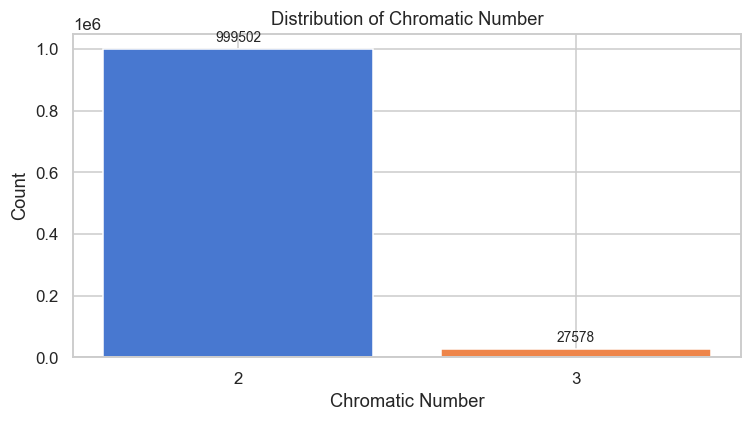

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df[TARGET].value_counts().sort_index()
bars = ax.bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted', len(vc)))
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel('Chromatic Number')
ax.set_ylabel('Count')
ax.set_title('Distribution of Chromatic Number')
plt.tight_layout()
plt.show()

## 3. Numeric property distributions by chromatic number

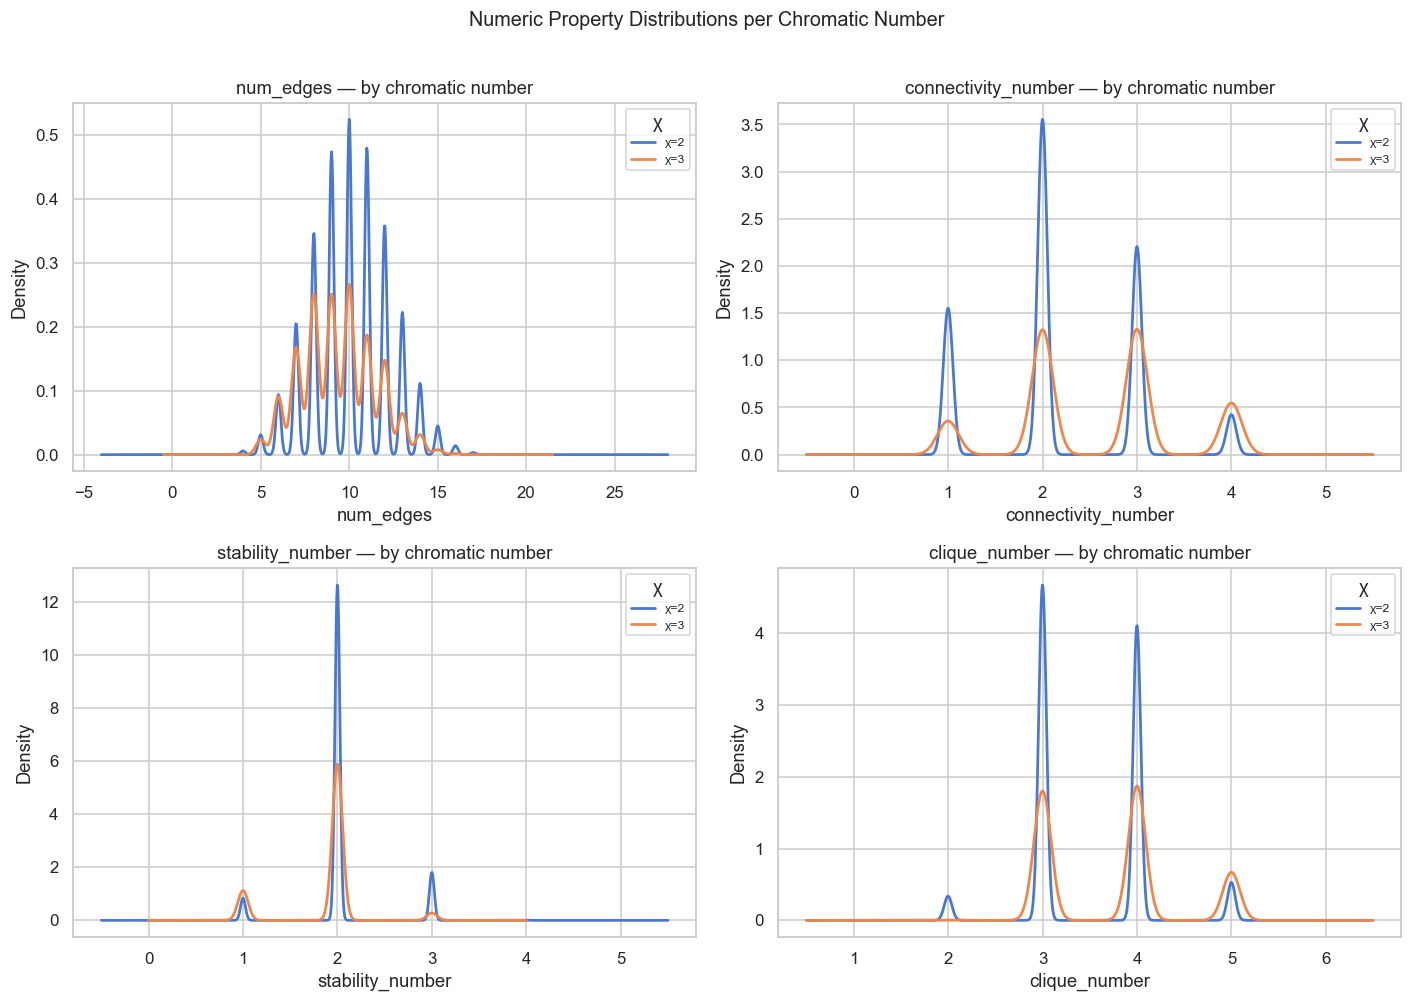

In [7]:
numeric_props = ['num_edges', 'connectivity_number', 'stability_number', 'clique_number']
chrom_vals = sorted(df[TARGET].unique())
palette = sns.color_palette('muted', len(chrom_vals))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, prop in zip(axes, numeric_props):
    for i, cv in enumerate(chrom_vals):
        subset = df.loc[df[TARGET] == cv, prop]
        subset.plot.kde(ax=ax, label=f'χ={cv}', color=palette[i], linewidth=1.8)
    ax.set_title(f'{prop} — by chromatic number')
    ax.set_xlabel(prop)
    ax.legend(title='χ', fontsize=8)

fig.suptitle('Numeric Property Distributions per Chromatic Number', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Boolean properties vs chromatic number

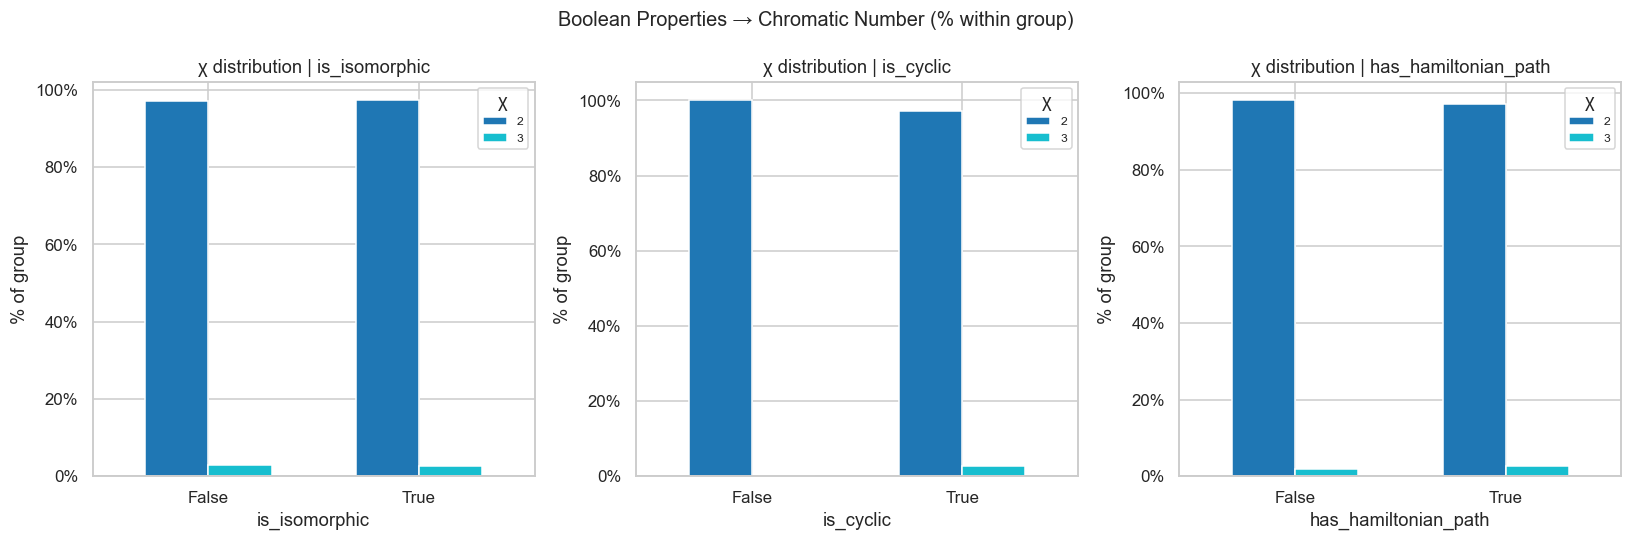

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, prop in zip(axes, bool_cols):
    ct = df.groupby([prop, TARGET]).size().unstack(fill_value=0)
    # Normalise to proportions within each boolean group
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.6)
    ax.set_title(f'χ distribution | {prop}')
    ax.set_xlabel(prop)
    ax.set_ylabel('% of group')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(title='χ', fontsize=8)

fig.suptitle('Boolean Properties → Chromatic Number (% within group)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Mean property values per chromatic number

                  num_edges  connectivity_number  stability_number  \
chromatic_number                                                     
2                    10.103                2.194             2.064   
3                     9.404                2.582             1.885   

                  clique_number  
chromatic_number                 
2                         3.501  
3                         3.737  


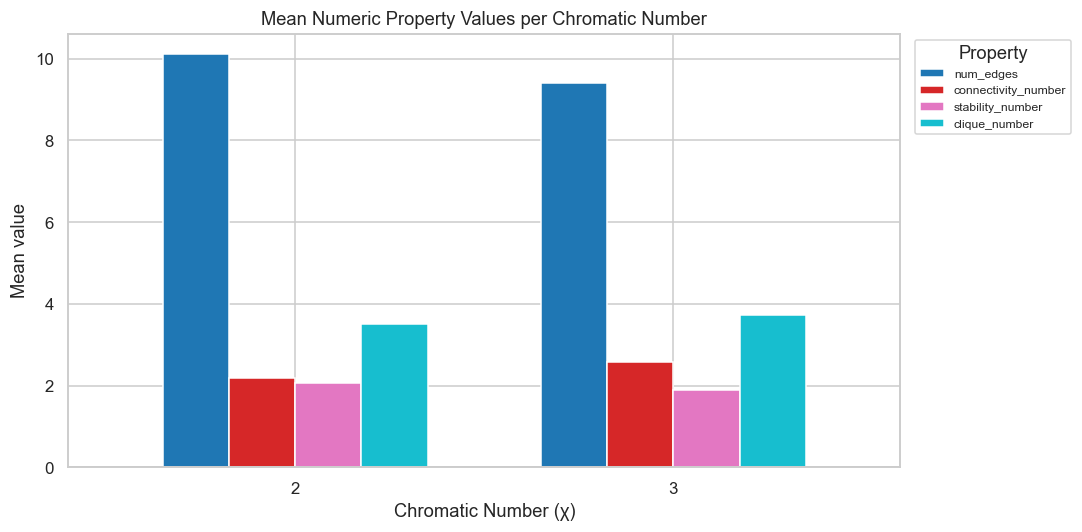

In [10]:
means = df.groupby(TARGET)[numeric_props].mean()
print(means.round(3))

ax = means.plot(kind='bar', figsize=(10, 5), width=0.7, colormap='tab10', edgecolor='white')
ax.set_title('Mean Numeric Property Values per Chromatic Number')
ax.set_xlabel('Chromatic Number (χ)')
ax.set_ylabel('Mean value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Property', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation heatmap (numeric columns)

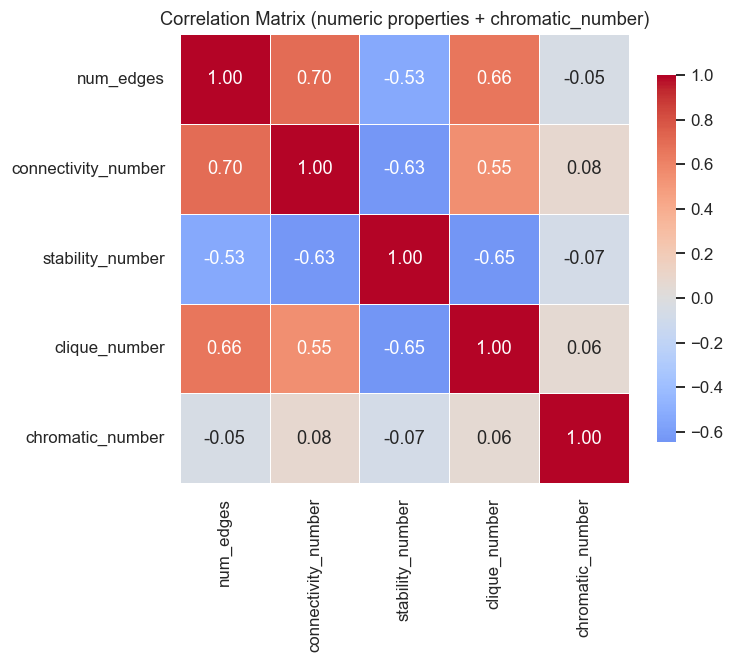

In [11]:
num_df = df[numeric_props + [TARGET]].copy()
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix (numeric properties + chromatic_number)')
plt.tight_layout()
plt.show()

## 7. Heatmap: num_edges × clique_number → mean chromatic number

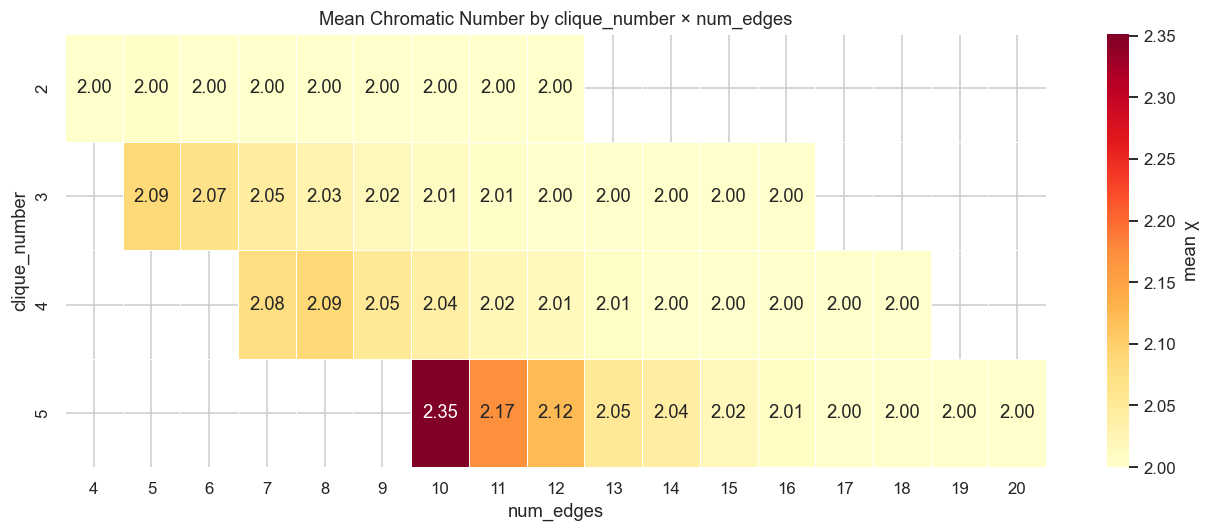

In [14]:
pivot = df.pivot_table(values=TARGET, index='clique_number', columns='num_edges', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'mean χ'})
ax.set_title('Mean Chromatic Number by clique_number × num_edges')
ax.set_xlabel('num_edges')
ax.set_ylabel('clique_number')
plt.tight_layout()
plt.show()

## 8. Boolean property prevalence per chromatic number (absolute counts)

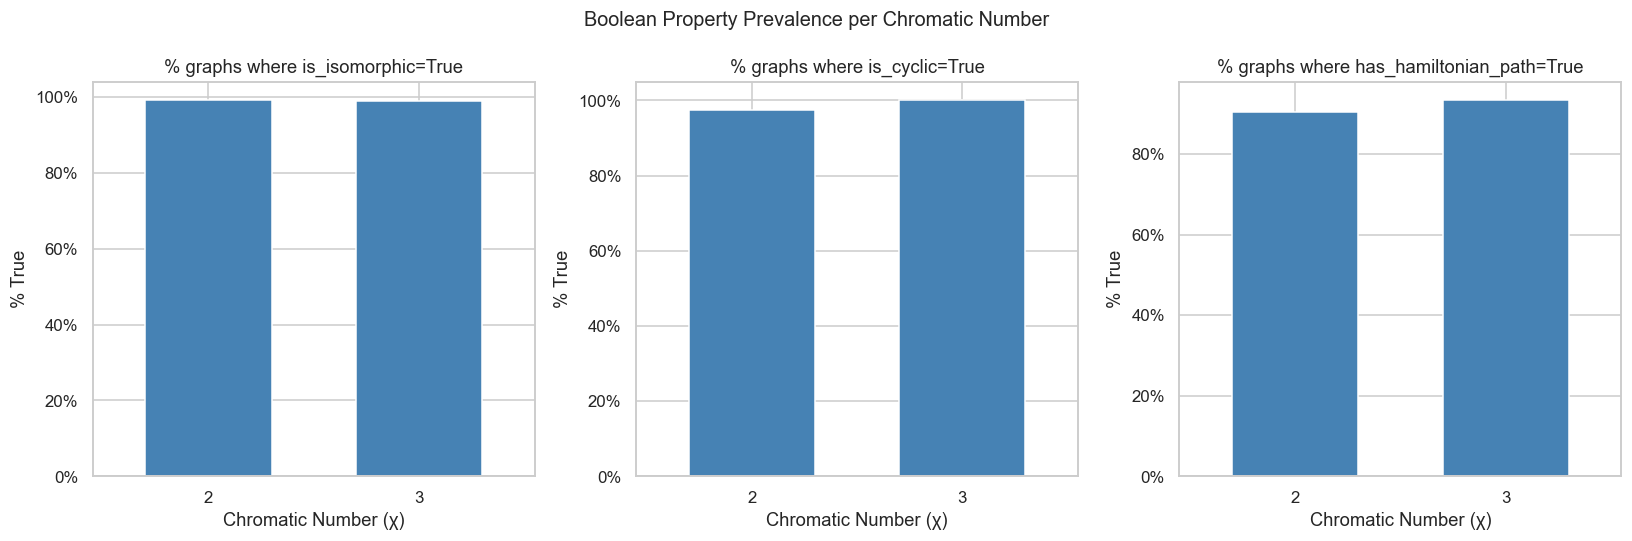

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, prop in zip(axes, bool_cols):
    # Fraction of True within each chromatic_number group
    frac = df.groupby(TARGET)[prop].mean() * 100
    frac.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
    ax.set_title(f'% graphs where {prop}=True')
    ax.set_xlabel('Chromatic Number (χ)')
    ax.set_ylabel('% True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle('Boolean Property Prevalence per Chromatic Number', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Summary table: mean properties per chromatic number (boolean + numeric)

In [16]:
summary = df.groupby(TARGET)[numeric_props + bool_cols].agg(
    {**{c: 'mean' for c in numeric_props}, **{c: 'mean' for c in bool_cols}}
).round(3)
summary.columns.name = 'property'
summary

property,num_edges,connectivity_number,stability_number,clique_number,is_isomorphic,is_cyclic,has_hamiltonian_path
chromatic_number,,,,,,,
2,10.103,2.194,2.064,3.501,0.991,0.974,0.904
3,9.404,2.582,1.885,3.737,0.990,1.000,0.933
